# Project Cycle 3: Two-Sample Inference Analysis

**Objective:** Compare the mean body weight between male and female students using the YRBS 2007 dataset. We will perform data cleaning, descriptive statistics, and conduct a Welch's Two-Sample t-test.

In [1]:
import pandas as pd
import numpy as np
import os

# 1. Load the original dataset
df_raw = pd.read_csv('../data/raw/YRBS_2007.csv')

print(f"Original dataset size: {df_raw.shape[0]} rows and {df_raw.shape[1]} columns")

Original dataset size: 14041 rows and 103 columns


## 1. Define Variables and Recoding Logic

Following the Project Cycle 3 guidelines for Question 4:

*   **Group Variable:** `WhatIsYourSex` (1 = Male, 2 = Female)
*   **Response Variable:** `HowMuchDoYouWeighWithoutShoesInKG` (Quantitative)
*   **Statistical Method:** Welch's Two-Sample t-test (Preferred for means comparison)[cite: 1]

In [3]:
# Select variables and drop missing values
df_analysis = df_raw[['WhatIsYourSex', 'HowMuchDoYouWeighWithoutShoesInKG']].dropna()

# 定義群組
male_w = df_analysis[df_analysis['WhatIsYourSex'] == 1]['HowMuchDoYouWeighWithoutShoesInKG']
female_w = df_analysis[df_analysis['WhatIsYourSex'] == 2]['HowMuchDoYouWeighWithoutShoesInKG']

print(f"Male sample: {len(male_w)}, Female sample: {len(female_w)}")

Male sample: 6490, Female sample: 6572


In [4]:
from scipy import stats

# Perform Welch's t-test (equal_var=False)[cite: 1]
t_stat, p_val = stats.ttest_ind(male_w, female_w, equal_var=False)

# Calculate difference in means[cite: 1]
mean_diff = male_w.mean() - female_w.mean()

print(f"Mean Difference: {mean_diff:.2f} kg")
print(f"Test Statistic (t): {t_stat:.4f}")
print(f"P-value: {p_val:.4e}") # Using scientific notation for small p-values

Mean Difference: -12.19 kg
Test Statistic (t): -43.9712
P-value: 0.0000e+00


## 2. Visual Comparison
We use a boxplot to visualize the weight distribution between genders as required.[cite: 1]

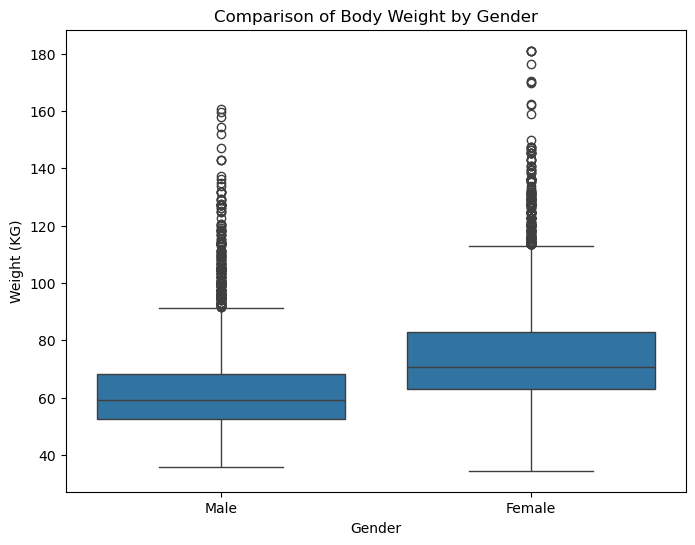

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(x='WhatIsYourSex', y='HowMuchDoYouWeighWithoutShoesInKG', data=df_analysis)
plt.xticks([0, 1], ['Male', 'Female'])
plt.title('Comparison of Body Weight by Gender')
plt.xlabel('Gender')
plt.ylabel('Weight (KG)')

# Save output[cite: 1]
plt.savefig('../outputs/figures/weight_boxplot.png')
plt.show()

In [6]:
import pandas as pd

# 建立摘要統計表[cite: 1]
summary_df = pd.DataFrame({
    'Group': ['Male', 'Female'],
    'Sample Size (n)': [len(male_w), len(female_w)],
    'Mean Weight (kg)': [male_w.mean(), female_w.mean()],
    'Std Dev': [male_w.std(), female_w.std()]
})

# 顯示在螢幕上
print("--- Summary Table ---")
print(summary_df)

# 儲存到指定資料夾[cite: 1]
summary_df.to_csv('../outputs/tables/weight_summary_table.csv', index=False)
print("\nSuccess: Summary table saved to outputs/tables/")

--- Summary Table ---
    Group  Sample Size (n)  Mean Weight (kg)    Std Dev
0    Male             6490         62.417296  14.163778
1  Female             6572         74.606528  17.374632

Success: Summary table saved to outputs/tables/


In [7]:
# 將清洗後的資料存檔，以利後續查驗
df_analysis.to_csv('../data/processed/cleaned_weight_data.csv', index=False)
print("Cleaned data saved to data/processed/")

Cleaned data saved to data/processed/
